<a href="https://colab.research.google.com/github/DavidTan-cloud/wqf7023-industrial-anomaly-detection-radar/blob/main/notebooks/02_smap_lstm_ae.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install pandas numpy matplotlib scikit-learn torch openpyxl

In [7]:
!git clone https://github.com/DavidTan-cloud/wqf7023-industrial-anomaly-detection-radar

Cloning into 'wqf7023-industrial-anomaly-detection-radar'...
remote: Enumerating objects: 272, done.
remote: Counting objects: 100% (272/272), done.
remote: Compressing objects: 100% (108/108), done.
remote: Total 272 (delta 195), reused 189 (delta 159), pack-reused 0 (from 0)
Receiving objects: 100% (272/272), 1.31 MiB | 8.38 MiB/s, done.
Resolving deltas: 100% (195/195), done.


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    roc_auc_score,
    confusion_matrix
)

import ast

In [16]:
REPO_DIR = "/content/wqf7023-industrial-anomaly-detection-radar"

TRAIN_DIR = f"{REPO_DIR}/src/datasets/raw/SMAP/train"
TEST_DIR = f"{REPO_DIR}/src/datasets/raw/SMAP/test"

CHANNEL = "A-1.npy"

In [17]:
import os

print(f"Contents of {REPO_DIR}:")
!ls -F {REPO_DIR}

print(f"\nContents of {REPO_DIR}/src/datasets/raw/SMAP/train:")
!ls -F {TRAIN_DIR}

print(f"\nContents of {REPO_DIR}/src/datasets/raw/SMAP/test:")
!ls -F {TEST_DIR}


Contents of /content/wqf7023-industrial-anomaly-detection-radar:
notebooks/  Readme.md  src/

Contents of /content/wqf7023-industrial-anomaly-detection-radar/src/datasets/raw/SMAP/train:
A-1.npy  C-2.npy   D-5.npy   E-3.npy  F-5.npy  M-3.npy	 P-3.npy   T-3.npy
A-2.npy  D-11.npy  D-6.npy   E-4.npy  F-7.npy  M-4.npy	 P-4.npy   T-4.npy
A-3.npy  D-12.npy  D-7.npy   E-5.npy  F-8.npy  M-5.npy	 P-7.npy   T-5.npy
A-4.npy  D-13.npy  D-8.npy   E-6.npy  G-1.npy  M-6.npy	 R-1.npy   T-8.npy
A-5.npy  D-14.npy  D-9.npy   E-7.npy  G-2.npy  M-7.npy	 S-1.npy   T-9.npy
A-6.npy  D-15.npy  E-10.npy  E-8.npy  G-3.npy  P-10.npy  S-2.npy
A-7.npy  D-16.npy  E-11.npy  E-9.npy  G-4.npy  P-11.npy  T-10.npy
A-8.npy  D-1.npy   E-12.npy  F-1.npy  G-6.npy  P-14.npy  T-12.npy
A-9.npy  D-2.npy   E-13.npy  F-2.npy  G-7.npy  P-15.npy  T-13.npy
B-1.npy  D-3.npy   E-1.npy   F-3.npy  M-1.npy  P-1.npy	 T-1.npy
C-1.npy  D-4.npy   E-2.npy   F-4.npy  M-2.npy  P-2.npy	 T-2.npy

Contents of /content/wqf7023-industrial-anomaly-det

In [18]:
import numpy as np
import os

# Ensure the directories exist before attempting to load
if not os.path.exists(TRAIN_DIR):
    print(f"Error: Training directory not found at {TRAIN_DIR}")
    # Optionally, you might want to create it or exit

if not os.path.exists(TEST_DIR):
    print(f"Error: Test directory not found at {TEST_DIR}")
    # Optionally, you might want to create it or exit

# Load the numpy files
# Added a check to see if the file exists before loading to prevent FileNotFoundError
if os.path.exists(f"{TRAIN_DIR}/{CHANNEL}"):
    train = np.load(
        f"{TRAIN_DIR}/{CHANNEL}"
    )
    print("Train Shape:", train.shape)
else:
    print(f"Error: Train file not found at {TRAIN_DIR}/{CHANNEL}")
    train = None # Or handle appropriately

if os.path.exists(f"{TEST_DIR}/{CHANNEL}"):
    test = np.load(
        f"{TEST_DIR}/{CHANNEL}"
    )
    print("Test Shape:", test.shape)
else:
    print(f"Error: Test file not found at {TEST_DIR}/{CHANNEL}")
    test = None # Or handle appropriately


Train Shape: (2880, 25)
Test Shape: (8640, 25)


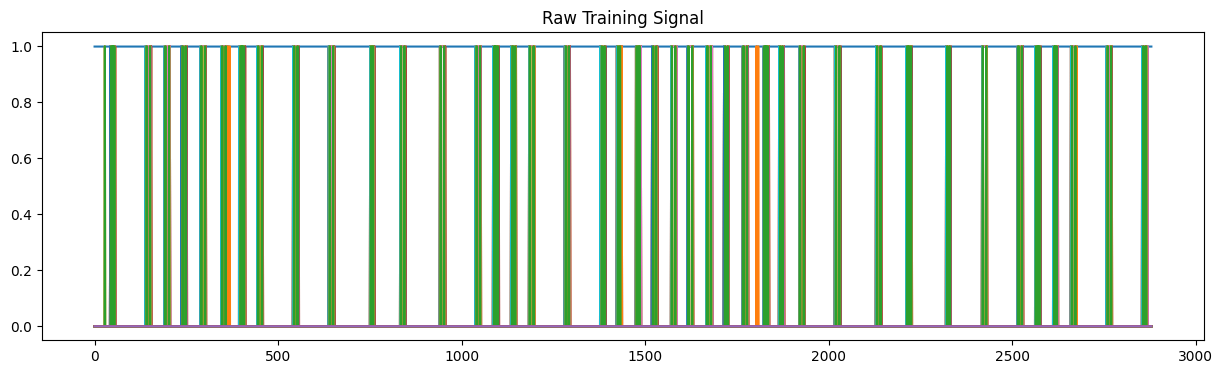

In [19]:
# Univariate
plt.figure(figsize=(15,4))
plt.plot(train)
plt.title("Raw Training Signal")
plt.show()

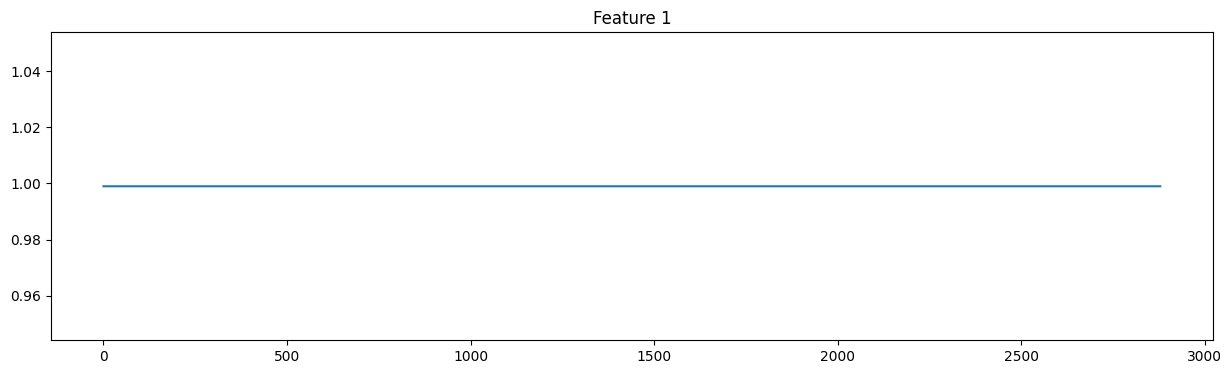

In [20]:
# Multivariate
plt.figure(figsize=(15,4))
plt.plot(train[:,0])
plt.title("Feature 1")
plt.show()

In [22]:
import pandas as pd

LABEL_FILE = "/content/wqf7023-industrial-anomaly-detection-radar/src/datasets/raw/SMAP/labeled_anomalies.csv"

labels_df = pd.read_csv(
    LABEL_FILE
)

labels_df.head()

,chan_id,spacecraft,anomaly_sequences,class,num_values
0,P-1,SMAP,"[[2149, 2349], [4536, 4844], [3539, 3779]]","[contextual, contextual, contextual]",8505
1,S-1,SMAP,"[[5300, 5747]]",[point],7331
2,E-1,SMAP,"[[5000, 5030], [5610, 6086]]","[contextual, contextual]",8516
3,E-2,SMAP,"[[5598, 6995]]",[point],8532
4,E-3,SMAP,"[[5094, 8306]]",[point],8307


In [23]:
row = labels_df[
    labels_df["chan_id"] == "A-1"
].iloc[0]

row

,15
chan_id,A-1
spacecraft,SMAP
anomaly_sequences,"[[4690, 4774]]"
class,[point]
num_values,8640


In [24]:
anomaly_sequence = row["anomaly_sequences"]

total_length = len(test)

print(anomaly_sequence)
print(total_length)

[[4690, 4774]]
8640


In [25]:
labels = np.zeros(
    total_length,
    dtype=int
)

intervals = ast.literal_eval(
    anomaly_sequence
)

for start, end in intervals:
    labels[start:end] = 1

print(
    "Number of anomalies:",
    labels.sum()
)

Number of anomalies: 84


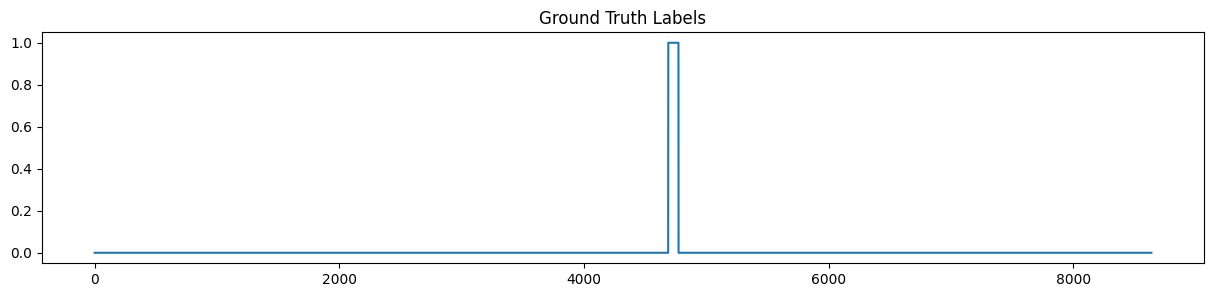

In [26]:
# Visualize Ground Truth
plt.figure(figsize=(15,3))
plt.plot(labels)
plt.title("Ground Truth Labels")
plt.show()

In [27]:
scaler = StandardScaler()

train_scaled = scaler.fit_transform(
    train
)

test_scaled = scaler.transform(
    test
)

In [28]:
# Create Sliding Windows
def create_windows(
    data,
    window_size=100
):
    windows = []
    for i in range(
        len(data) - window_size
    ):
        windows.append(
            data[i:i+window_size]
        )
    return np.array(windows)

In [29]:
WINDOW_SIZE = 100

X_train = create_windows(
    train_scaled,
    WINDOW_SIZE
)

X_test = create_windows(
    test_scaled,
    WINDOW_SIZE
)

print(X_train.shape)
print(X_test.shape)

(2780, 100, 25)
(8540, 100, 25)


In [30]:
def create_window_labels(
    labels,
    window_size
):
    y = []
    for i in range(
        len(labels)-window_size
    ):
        y.append(
            int(
                labels[i:i+window_size].max()
            )
        )

    return np.array(y)

In [31]:
y_test = create_window_labels(
    labels,
    WINDOW_SIZE
)

print(y_test.shape)

(8540,)


In [32]:
X_train_t = torch.FloatTensor(
    X_train
)

X_test_t = torch.FloatTensor(
    X_test
)

In [33]:
# LSTM AE
class LSTMAE(nn.Module):

    def __init__(
        self,
        input_dim,
        hidden_dim=64
    ):

        super().__init__()

        self.encoder = nn.LSTM(
            input_dim,
            hidden_dim,
            batch_first=True
        )

        self.decoder = nn.LSTM(
            hidden_dim,
            input_dim,
            batch_first=True
        )

    def forward(self, x):
        encoded, _ = self.encoder(x)
        decoded, _ = self.decoder(encoded)

        return decoded

In [34]:
input_dim = X_train.shape[-1]

model = LSTMAE(
    input_dim=input_dim
)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [35]:
loss_history = []

EPOCHS = 20

for epoch in range(EPOCHS):
    optimizer.zero_grad()
    output = model(X_train_t)
    loss = criterion(
        output,
        X_train_t
    )

    loss.backward()
    optimizer.step()
    loss_history.append(
        loss.item()
    )

    print(
        f"Epoch {epoch+1}: "
        f"{loss.item():.6f}"
    )

Epoch 1: 0.706683
Epoch 2: 0.704047
Epoch 3: 0.701518
Epoch 4: 0.699081
Epoch 5: 0.696722
Epoch 6: 0.694430
Epoch 7: 0.692189
Epoch 8: 0.689989
Epoch 9: 0.687818
Epoch 10: 0.685663
Epoch 11: 0.683515
Epoch 12: 0.681366
Epoch 13: 0.679206
Epoch 14: 0.677030
Epoch 15: 0.674830
Epoch 16: 0.672604
Epoch 17: 0.670351
Epoch 18: 0.668073
Epoch 19: 0.665775
Epoch 20: 0.663465


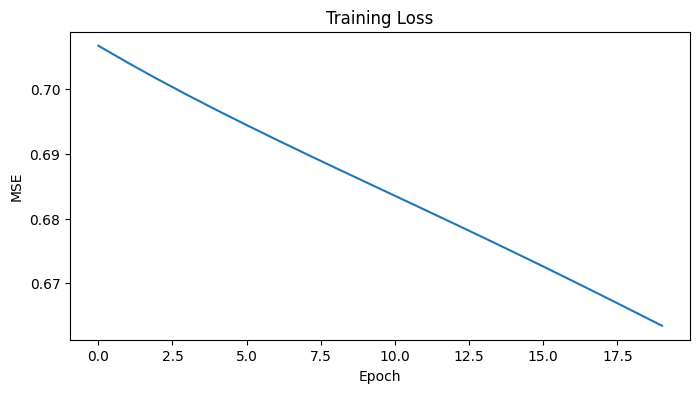

In [36]:
plt.figure(figsize=(8,4))
plt.plot(loss_history)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.show()

In [37]:
with torch.no_grad():
    reconstruction = model(X_test_t)
    scores = (( X_test_t -reconstruction) ** 2).mean(dim=(1,2)).numpy()

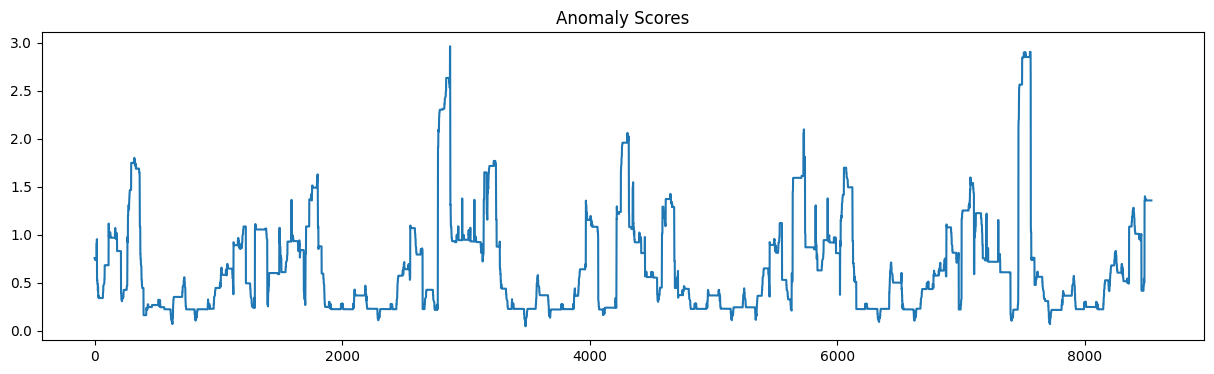

In [38]:
plt.figure(figsize=(15,4))
plt.plot(scores)
plt.title("Anomaly Scores")
plt.show()

In [39]:
threshold = (scores.mean() + 2 * scores.std())
preds = (scores > threshold).astype(int)
print("Threshold:", threshold)

Threshold: 1.6734189


In [40]:
results = {
    "Accuracy":
        accuracy_score(
            y_test,
            preds
        ),

    "Precision":
        precision_score(
            y_test,
            preds
        ),

    "Recall":
        recall_score(
            y_test,
            preds
        ),

    "F1":
        f1_score(
            y_test,
            preds
        ),

    "AUC":
        roc_auc_score(
            y_test,
            scores
        )
}

results

{'Accuracy': 0.9300936768149883,
 'Precision': 0.0,
 'Recall': 0.0,
 'F1': 0.0,
 'AUC': np.float64(0.690272413231668)}

In [41]:
cm = confusion_matrix(
    y_test,
    preds
)

cm

array([[7943,  414],
       [ 183,    0]])

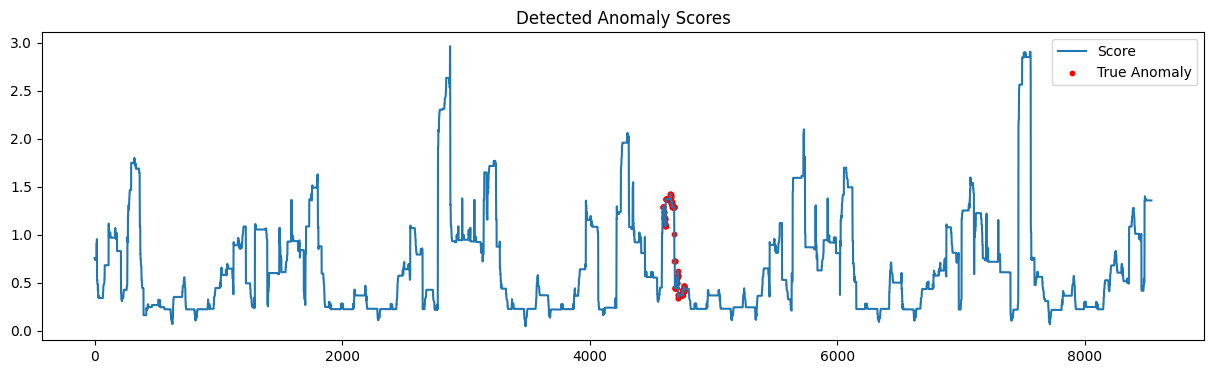

In [42]:
plt.figure(figsize=(15,4))
plt.plot(scores, label="Score")

anomalies = np.where(y_test == 1)[0]

plt.scatter(
    anomalies,
    scores[anomalies],
    color="red",
    s=10,
    label="True Anomaly"
)

plt.legend()
plt.title("Detected Anomaly Scores")
plt.show()

In [43]:
results_df = pd.DataFrame([results])
results_df.to_csv("SMAP_A1_LSTM_AE.csv", index=False)
results_df


,Accuracy,Precision,Recall,F1,AUC
0,0.930094,0.0,0.0,0.0,0.690272


In [44]:
print("Normal Windows:", np.sum(y_test == 0))
print("Anomaly Windows:", np.sum(y_test == 1))

Normal Windows: 8357
Anomaly Windows: 183


In [45]:
print("Predicted Normal:", np.sum(preds == 0))
print("Predicted Anomaly:", np.sum(preds == 1))

Predicted Normal: 8126
Predicted Anomaly: 414


In [46]:
print(results)

{'Accuracy': 0.9300936768149883, 'Precision': 0.0, 'Recall': 0.0, 'F1': 0.0, 'AUC': np.float64(0.690272413231668)}
